<a href="https://colab.research.google.com/github/BenjaminBeltran27/GE2-Tarea1/blob/main/problema1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

--- RESUMEN DE LA SIMULACIÓN ---
Paso espacial (dx): 0.0005 m
Paso temporal (dt): 0.0521 s
Temperatura máxima final: 377.480 K en x = 0.0100 m

Análisis de Estabilidad Física:
Beta actual = 1000.0 W/m3K
Beta crítico (h/L) = 1500.0 W/m3K
-> El sistema es ESTABLE (Alcanzará un estado estacionario).


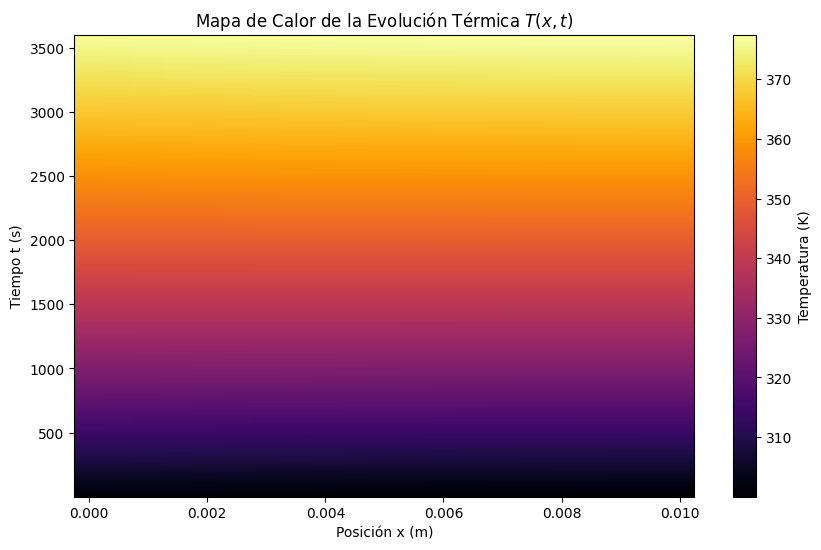

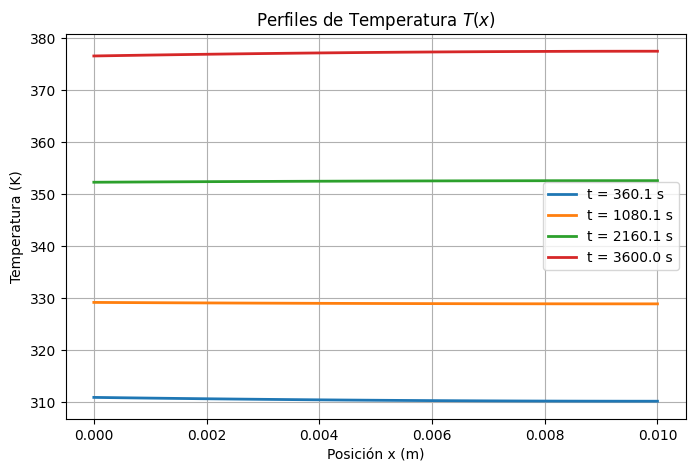

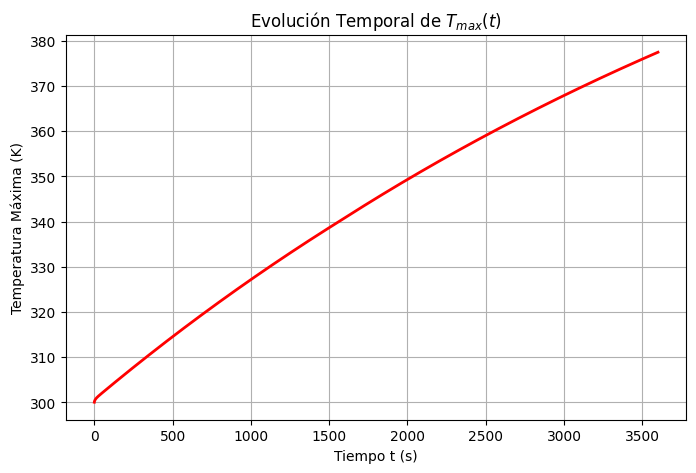

In [3]:
import numpy as np
import matplotlib.pyplot as plt

# 1. PARÁMETROS DEL SISTEMA (Batería Ion-Litio)

# Justificación de valores propuestos:
L = 0.01          # Espesor (m)
rho = 2500.0      # Densidad (kg/m3)
cp = 1000.0       # Calor específico (J/kgK)
k = 3.0           # Conductividad térmica (W/mK)
alpha = k / (rho * cp)

# Condiciones de frontera
h = 15.0          # Coef. convectivo (W/m2K)
T_inf = 300.0     # Temp. ambiente (K)
q_sol = 600.0     # Flujo solar (W/m2)

# Generación interna (Modelo Linealizado: q''' = q_r + beta*(T - T_r))
T_r = 300.0       # Temp. de referencia (K).
q_r = 15000.0     # Generación base (W/m3).
beta = 1000.0     # Parámetro beta (W/m3K).
T_ini = 300.0     # Temperatura inicial uniforme (K) en t=0.


# 2. DISCRETIZACIÓN ESPACIAL Y TEMPORAL

N = 21            # Número de nodos
dx = L / (N - 1)
x = np.linspace(0, L, N)

# Criterio de estabilidad (Fourier < 0.5)
Fo = 0.25         # Número de Fourier
dt = Fo * (dx**2) / alpha  # Paso de tiempo (s)
t_final = 3600.0  # Simular 1 hora
num_steps = int(t_final / dt)


# 3. MATRICES Y CONDICIÓN INICIAL

T = np.ones(N) * T_ini
T_historial = np.zeros((num_steps, N))
tiempos = np.zeros(num_steps)
T_max_array = np.zeros(num_steps)
pos_max_array = np.zeros(num_steps)


# 4. SOLUCIÓN NUMÉRICA
for n in range(num_steps):
    T_new = np.zeros(N)

    # Generación interna actual
    q_gen = q_r + beta * (T - T_r)

    # Nodo 0 (x=0): Frontera con Radiación Solar y Convección
    # Balance de energía en un volumen de control de ancho dx/2
    T_new[0] = T[0] + (2 * dt / (rho * cp * dx)) * (
        q_sol - h * (T[0] - T_inf) + k * (T[1] - T[0]) / dx + q_gen[0] * dx / 2
    )

    # Nodos Interiores (x=1 a N-2): Conducción 1D con generación
    for i in range(1, N - 1):
        T_new[i] = T[i] + Fo * (T[i-1] - 2*T[i] + T[i+1]) + (dt / (rho * cp)) * q_gen[i]

    # Nodo N-1 (x=L): Frontera Adiabática (dT/dx = 0)
    # Balance de energía en un volumen de control de ancho dx/2
    T_new[-1] = T[-1] + (2 * dt / (rho * cp * dx)) * (
        k * (T[-2] - T[-1]) / dx + q_gen[-1] * dx / 2
    )

    # Actualizar estado
    T = np.copy(T_new)

    # Guardar
    T_historial[n, :] = T
    tiempos[n] = (n + 1) * dt
    T_max_array[n] = np.max(T)
    pos_max_array[n] = x[np.argmax(T)]


# 5. GRÁFICOS Y RESULTADOS

print("--- RESUMEN DE LA SIMULACIÓN ---")
print(f"Paso espacial (dx): {dx:.4f} m")
print(f"Paso temporal (dt): {dt:.4f} s")
print(f"Temperatura máxima final: {T_max_array[-1]:.3f} K en x = {pos_max_array[-1]:.4f} m")

# Condición teórica de estabilidad del sistema
beta_critico = h / L
print(f"\nAnálisis de Estabilidad Física:")
print(f"Beta actual = {beta} W/m3K")
print(f"Beta crítico (h/L) = {beta_critico} W/m3K")
if beta < beta_critico:
    print("-> El sistema es ESTABLE (Alcanzará un estado estacionario).")
else:
    print("-> El sistema es INESTABLE (Fuga térmica inminente).")

#Figura 1: Mapa de calor T(x,t)
plt.figure(figsize=(10, 6))
# Transponer la matriz para que el tiempo sea el eje Y y el espacio el eje X
X, Time = np.meshgrid(x, tiempos)
plt.pcolormesh(X, Time, T_historial, shading='auto', cmap='inferno')
plt.colorbar(label='Temperatura (K)')
plt.xlabel('Posición x (m)')
plt.ylabel('Tiempo t (s)')
plt.title('Mapa de Calor de la Evolución Térmica $T(x,t)$')
plt.savefig('mapacalor.png', dpi=300, bbox_inches='tight') # <-- Guarda la imagen
plt.show()

#Figura 2: Perfiles de temperatura T(x) en 4 tiempos
plt.figure(figsize=(8, 5))
indices_tiempo = [int(num_steps*0.1), int(num_steps*0.3), int(num_steps*0.6), -1]
for idx in indices_tiempo:
    plt.plot(x, T_historial[idx, :], label=f't = {tiempos[idx]:.1f} s', linewidth=2)
plt.xlabel('Posición x (m)')
plt.ylabel('Temperatura (K)')
plt.title('Perfiles de Temperatura $T(x)$')
plt.legend()
plt.grid(True)
plt.savefig('perfiles.png', dpi=300, bbox_inches='tight')
plt.show()

#Figura 3: Evolución de la Temperatura Máxima T_max(t)
plt.figure(figsize=(8, 5))
plt.plot(tiempos, T_max_array, 'r-', linewidth=2)
plt.xlabel('Tiempo t (s)')
plt.ylabel('Temperatura Máxima (K)')
plt.title('Evolución Temporal de $T_{max}(t)$')
plt.grid(True)
plt.savefig('evoluciontemp.png', dpi=300, bbox_inches='tight')
plt.show()